# EDA — Home Credit Default Risk: `previous_application.csv`

## Purpose of this notebook

`previous_application.csv` contains this institution's own history with
each client — every previous loan/credit application, whether it was
approved, refused, canceled, or left as an unused offer.

Unlike `bureau.csv` (other institutions, less detail available), Home
Credit has full visibility into *why* a previous application went the way
it did — which makes `NAME_CONTRACT_STATUS` one of the most promising
columns in the whole dataset: a client who was previously refused, or who
repeatedly canceled applications, is a very different risk profile than one
with a clean approval history.

Same one-to-many relationship with `SK_ID_CURR` as `bureau.csv`. This
notebook follows the same structure, including the lesson learned there:
check rare/sparse events as binary flags, not just raw averages.

1. Load the table, check shape/types
2. Explore the one-to-many relationship with `SK_ID_CURR`
3. Review missing values
4. Look at `NAME_CONTRACT_STATUS` — the key categorical field
5. Look at key numeric fields (requested vs. approved amounts, days since decision)
6. Early signal check: aggregate per client and merge with the target


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

prev = pd.read_csv("../data/raw/home_credit/previous_application.csv")
print(f"Shape: {prev.shape[0]:,} rows x {prev.shape[1]} columns")
prev.head()

Shape: 1,670,214 rows x 37 columns


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Data types and general shape

In [10]:
prev.info(verbose=False)
print()
print(prev.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Columns: 37 entries, SK_ID_PREV to NFLAG_INSURED_ON_APPROVAL
dtypes: float64(15), int64(6), object(16)
memory usage: 471.5+ MB

object     16
float64    15
int64       6
Name: count, dtype: int64


## 2. One-to-many relationship with `SK_ID_CURR`

In [11]:
app_train = pd.read_csv("../data/raw/home_credit/application_train.csv", usecols=["SK_ID_CURR", "TARGET"])
n_total_clients = app_train["SK_ID_CURR"].nunique()

n_unique_clients_in_prev = prev["SK_ID_CURR"].nunique()

# IMPORTANT: previous_application.csv is NOT limited to application_train
# clients -- it also includes clients that only appear in
# application_test.csv (the competition's held-out test set). That means
# n_unique_clients_in_prev (338,857) can be LARGER than n_total_clients
# (307,511), and a naive subtraction here would give a nonsensical negative
# number. The correct way to count "clients with no previous application"
# is to explicitly merge against app_train, never to subtract raw totals
# from two tables that aren't guaranteed to be subsets of one another.
clients_in_train_with_prev = app_train["SK_ID_CURR"].isin(prev["SK_ID_CURR"]).sum()
n_clients_with_no_prev_app = n_total_clients - clients_in_train_with_prev

print(f"Total previous_application rows: {len(prev):,}")
print(f"Unique clients in previous_application.csv (train + test combined): {n_unique_clients_in_prev:,}")
print(f"Of those, clients that are also in application_train: {clients_in_train_with_prev:,}")
print(f"application_train clients with NO previous application at all: {n_clients_with_no_prev_app:,} "
      f"({n_clients_with_no_prev_app / n_total_clients:.1%})")

records_per_client = prev.groupby("SK_ID_CURR").size()
print()
print("Distribution of previous applications per client (clients WITH at least 1, train+test combined):")
print(records_per_client.describe())

Total previous_application rows: 1,670,214
Unique clients in previous_application.csv (train + test combined): 338,857
Of those, clients that are also in application_train: 291,057
application_train clients with NO previous application at all: 16,454 (5.4%)

Distribution of previous applications per client (clients WITH at least 1, train+test combined):
count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          77.000000
dtype: float64


## 3. Missing values overview

In [12]:
missing = prev.isna().sum()
missing_pct = (missing / len(prev) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

RATE_INTEREST_PRIVILEGED     99.643698
RATE_INTEREST_PRIMARY        99.643698
AMT_DOWN_PAYMENT             53.636480
RATE_DOWN_PAYMENT            53.636480
NAME_TYPE_SUITE              49.119754
NFLAG_INSURED_ON_APPROVAL    40.298129
DAYS_TERMINATION             40.298129
DAYS_LAST_DUE                40.298129
DAYS_LAST_DUE_1ST_VERSION    40.298129
DAYS_FIRST_DUE               40.298129
DAYS_FIRST_DRAWING           40.298129
AMT_GOODS_PRICE              23.081773
AMT_ANNUITY                  22.286665
CNT_PAYMENT                  22.286366
PRODUCT_COMBINATION           0.020716
AMT_CREDIT                    0.000060
dtype: float64


## 4. `NAME_CONTRACT_STATUS` — the key categorical field

Whether each previous application was approved, refused, canceled, or left
as an unused offer.

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

NAME_CONTRACT_STATUS
Approved        62.1
Canceled        18.9
Refused         17.4
Unused offer     1.6
Name: count, dtype: float64


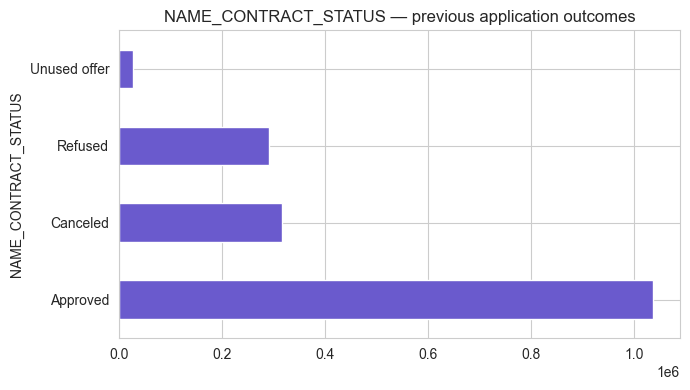

In [13]:
status_counts = prev["NAME_CONTRACT_STATUS"].value_counts()
print(status_counts)
print()
print((status_counts / len(prev) * 100).round(1))

plt.figure(figsize=(7, 4))
status_counts.plot(kind="barh", color="slateblue")
plt.title("NAME_CONTRACT_STATUS — previous application outcomes")
plt.tight_layout()
plt.show()

## 5. Key numeric fields

`AMT_APPLICATION` (amount requested) vs. `AMT_CREDIT` (amount actually
granted) — a large gap between the two can itself be informative.
`DAYS_DECISION` tells us how long ago the decision was made.

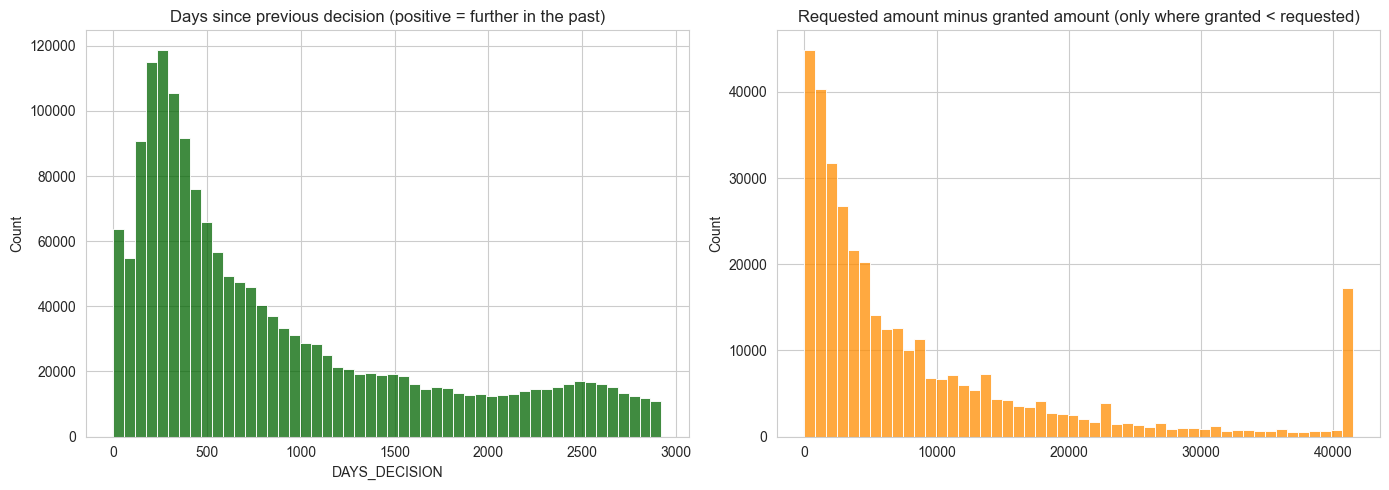

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(-prev["DAYS_DECISION"], bins=50, ax=axes[0], color="darkgreen")
axes[0].set_title("Days since previous decision (positive = further in the past)")

gap = (prev["AMT_APPLICATION"] - prev["AMT_CREDIT"]).clip(lower=0)
sns.histplot(gap[gap > 0].clip(upper=gap.quantile(0.99)), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Requested amount minus granted amount (only where granted < requested)")

plt.tight_layout()
plt.show()

## 6. Early signal check: does previous-application history correlate with the target?

Following the lesson from `bureau.csv`: check both simple counts AND binary
flags for less frequent outcomes (refused, canceled), since rare events can
carry strong signal that gets hidden in averages.

In [15]:
prev_summary = prev.groupby("SK_ID_CURR").agg(
    PREV_APP_COUNT=("SK_ID_PREV", "count"),
    PREV_REFUSED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    PREV_CANCELED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Canceled").sum()),
    PREV_APPROVED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
).reset_index()

prev_summary["EVER_REFUSED"] = (prev_summary["PREV_REFUSED_COUNT"] > 0).astype(int)
prev_summary["EVER_CANCELED"] = (prev_summary["PREV_CANCELED_COUNT"] > 0).astype(int)
prev_summary["REFUSAL_RATE"] = prev_summary["PREV_REFUSED_COUNT"] / prev_summary["PREV_APP_COUNT"]

merged = app_train.merge(prev_summary, on="SK_ID_CURR", how="left")
merged["PREV_APP_COUNT"] = merged["PREV_APP_COUNT"].fillna(0)
merged["EVER_REFUSED"] = merged["EVER_REFUSED"].fillna(0)
merged["EVER_CANCELED"] = merged["EVER_CANCELED"].fillna(0)
merged["HAS_PREV_APP_HISTORY"] = (merged["PREV_APP_COUNT"] > 0).astype(int)

print("Default rate by whether the client has ANY previous application history:")
print(merged.groupby("HAS_PREV_APP_HISTORY")["TARGET"].agg(["mean", "count"]))
print()
print("Default rate by EVER_REFUSED (0 = never refused before, 1 = refused at least once):")
print(merged.groupby("EVER_REFUSED")["TARGET"].agg(["mean", "count"]))
print()
print("Default rate by EVER_CANCELED (0 = never canceled before, 1 = canceled at least once):")
print(merged.groupby("EVER_CANCELED")["TARGET"].agg(["mean", "count"]))

Default rate by whether the client has ANY previous application history:
                          mean   count
HAS_PREV_APP_HISTORY                  
0                     0.059560   16454
1                     0.081926  291057

Default rate by EVER_REFUSED (0 = never refused before, 1 = refused at least once):
                  mean   count
EVER_REFUSED                  
0.0           0.069845  207217
1.0           0.103217  100294

Default rate by EVER_CANCELED (0 = never canceled before, 1 = canceled at least once):
                   mean   count
EVER_CANCELED                  
0.0            0.077480  196785
1.0            0.086502  110726


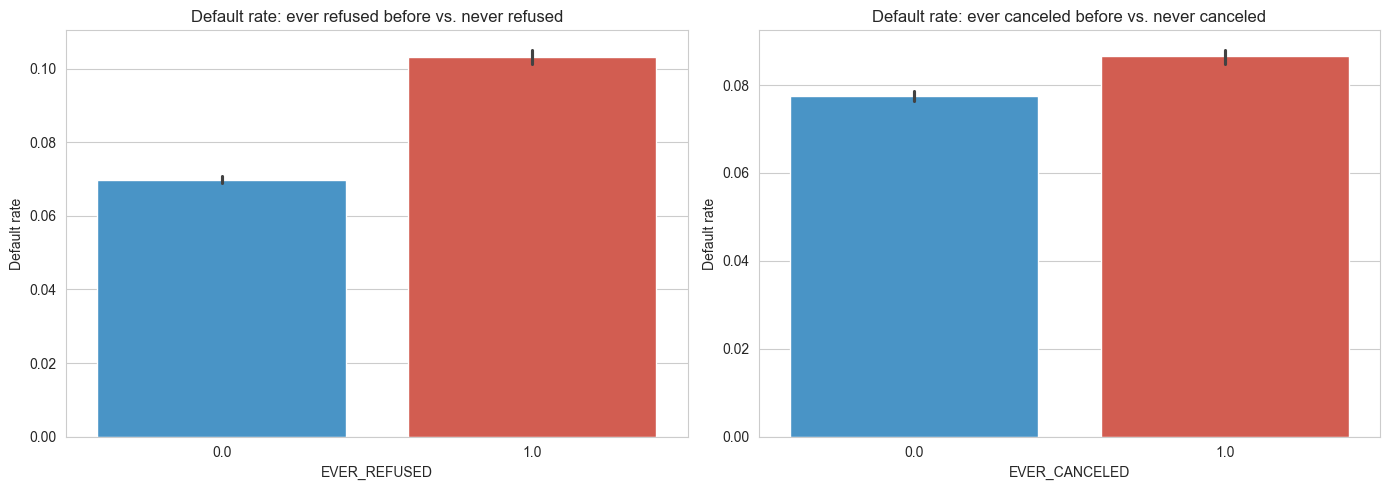

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=merged, x="EVER_REFUSED", y="TARGET", hue="EVER_REFUSED",
            palette=["#3498db", "#e74c3c"], legend=False, ax=axes[0])
axes[0].set_title("Default rate: ever refused before vs. never refused")
axes[0].set_ylabel("Default rate")

sns.barplot(data=merged, x="EVER_CANCELED", y="TARGET", hue="EVER_CANCELED",
            palette=["#3498db", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Default rate: ever canceled before vs. never canceled")
axes[1].set_ylabel("Default rate")

plt.tight_layout()
plt.show()

## 7. Summary and next steps
- 5.35% of application_train clients (16,454 of 307,511) have no previous application history at all — the remaining 94.65% (291,057) have at least one.
- `NAME_CONTRACT_STATUS` distribution: Approved 62.1%, Canceled 18.9%, Refused 17.4%, Unused offer 1.6% — nearly 1 in 5 previous applications ends up refused or canceled.
- `EVER_REFUSED` shows a strong effect: clients never refused before default at **6.98%**, versus **10.32%** for those refused at least once — a 48% relative increase.
- `EVER_CANCELED` shows a weaker but still present effect: 7.75% vs. 8.65% (12% relative increase).
- `HAS_PREV_APP_HISTORY` behaves **opposite** to `HAS_BUREAU_HISTORY`: here, having previous-application history correlates with **higher** risk (8.19% vs. 5.96% for no history), while in `bureau.csv` having *no* history was the riskier case. This isn't a contradiction — the two capture different behaviors: repeated applications to the same institution may signal recurring financial need, while external bureau presence reflects general credit experience.

**Methodological note:** found and fixed a bug in section 2 — `previous_application.csv` includes clients from `application_test.csv` as well, so its total unique-client count isn't a subset of `application_train`'s. Counting "clients with no history" must always be done via an explicit merge/`isin` check against `application_train`, never by subtracting raw totals between two tables that aren't guaranteed to be subsets of one another.

**Next:** the payment-level tables (`installments_payments.csv`, `credit_card_balance.csv`) — the most granular, most genuinely *behavioral* tables in the dataset, showing month-by-month and installment-by-installment payment patterns rather than static summaries.
